# 06 — Gesture Morphology (P2)

## The question

Watching people use the app, some **fling** the content and let it coast; others **hold
and drag** it down under the finger. That is obviously behavioural and obviously not
captured by anything in the pipeline, which counts scroll events without ever asking what
kind of gesture produced them.

This notebook asks what *kind* of contact each touch is, rather than how fast or how
often it happened.

## The discriminator

A fling and a drag differ physically in one observable way: **momentum**. Release a fling
and the content keeps moving, so `scroll` events continue firing after `touchend`. A drag
moves content only while the finger is down, so scrolling stops dead at release. That
single distinction is enough to classify every scroll gesture, and it validates itself —
the two classes come out with the physical properties they should.

## What the notebook finds

The binary answer turns out to be the less interesting half. Everyone flings most of the
time (69–91% of scroll gestures), and fling ratio correlates about −0.9 with pace, so on
its own it largely re-measures tempo.

The **morphology within a gesture** is where the behaviour is. How far the finger travels
per push, how long it stays down, and how much scroll distance is obtained per millisecond
of contact vary several-fold between people, and — unlike almost everything else in this
project — **push distance is essentially uncorrelated with pace**. That makes it one of
the few features here measuring something genuinely independent of how fast someone works.

## Scope and standing caveat

Mobile only. Six participants, one handset each, so nothing here separates person from
device. Screen dimensions in particular scale every distance feature directly, which
matters more in this notebook than in the timing ones — see Section 8.


## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pd.set_option('display.max_columns', 60); pd.set_option('display.width', 210)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.22,
                     'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9})

RAW_EVENTS_PARQUET = "../../data/processed/raw_events.parquet"
RAW_EVENTS_CSV = "../../data/processed/raw_events.csv"
if Path(RAW_EVENTS_PARQUET).exists():
    raw_all = pd.read_parquet(RAW_EVENTS_PARQUET); _src = RAW_EVENTS_PARQUET
else:
    raw_all = pd.read_csv(RAW_EVENTS_CSV, low_memory=False); _src = RAW_EVENTS_CSV

raw_all['deviceFamily'] = raw_all['deviceFamily'].astype(str).str.lower()
raw_all['tRelMs'] = pd.to_numeric(raw_all['tRelMs'], errors='coerce')
raw_all = raw_all.loc[raw_all['tRelMs'].notna()].copy()
raw = raw_all.loc[raw_all['deviceFamily'] == 'mobile'].copy()

TOUCH_START, TOUCH_END, TOUCH_MOVE = 'touchstart', 'touchend', 'touchmove'
# carousel_scroll carries no scrollTop payload, so it cannot contribute distance.
SCROLL_KINDS = ['scroll', 'window_scroll']
CAROUSEL_KIND = 'carousel_scroll'

session_index = (raw.groupby(['participantId', 'sessionId'], dropna=False)
                 .agg(duration_s=('tRelMs', lambda s: s.max() / 1000.0),
                      started=('timestampIso', 'min')).reset_index())
session_index['session_start'] = pd.to_datetime(session_index['started'], utc=True, errors='coerce')
session_index = session_index.sort_values(['participantId', 'session_start']).reset_index(drop=True)
session_index['observed_session_number'] = session_index.groupby('participantId').cumcount() + 1

_p_dur = session_index.groupby('participantId')['duration_s'].median().sort_values(ascending=False)
PARTICIPANT_ORDER = _p_dur.index.astype(str).tolist()
PARTICIPANT_COLORS = {p: plt.get_cmap('turbo')((i + 0.5) / max(1, len(PARTICIPANT_ORDER)))
                      for i, p in enumerate(PARTICIPANT_ORDER)}
def pcolor(p): return PARTICIPANT_COLORS.get(str(p), '0.5')

_n_car = int((raw['kind'] == CAROUSEL_KIND).sum())
print(f"Loaded {_src}")
print(f"mobile: {len(raw):,} events | {raw['sessionId'].nunique()} sessions | "
      f"{raw['participantId'].nunique()} participants")
if _n_car:
    print(f"\nNOTE: {_n_car:,} {CAROUSEL_KIND} events carry no scrollTop and are excluded from")
    print("      all distance measures. Horizontal carousel behaviour is invisible until")
    print("      the logger records a position for them.")

Loaded ../../data/processed/raw_events.parquet
mobile: 227,356 events | 13 sessions | 6 participants

NOTE: 4,320 carousel_scroll events carry no scrollTop and are excluded from
      all distance measures. Horizontal carousel behaviour is invisible until
      the logger records a position for them.


## 2. Extracting touch interactions

One row per `touchstart`→`touchend` pair, matched by the same O(n) stack pass used
elsewhere in the project, with the `touchmove` path and any scroll activity attached.

Two quantities are recorded either side of release, and the distinction between them is
the whole basis of the classification: **`scroll_during`** is content movement while the
finger is down, **`scroll_coast`** is content movement in the window *after* the finger
lifts.

In [2]:
COAST_WINDOW_MS = 2000.0     # how long after release to look for momentum
MAX_INTERACTION_MS = 8000.0  # anything longer is not a gesture; likely a stuck pointer


def _pair_touches(sess):
    st = sess.loc[sess['kind'] == TOUCH_START, ['tRelMs', 'payload_x', 'payload_y']].to_numpy(float)
    en = sess.loc[sess['kind'] == TOUCH_END, ['tRelMs', 'payload_x', 'payload_y']].to_numpy(float)
    ev = [(r[0], 0, i) for i, r in enumerate(st)] + [(r[0], 1, i) for i, r in enumerate(en)]
    ev.sort(key=lambda e: (e[0], e[1]))
    stack, out = [], []
    for _t, kind, i in ev:
        if kind == 0:
            stack.append(i)
        elif stack:
            out.append((stack.pop(), i))
    return st, en, sorted(out, key=lambda o: st[o[0]][0])


def extract_interactions(raw_df):
    rows = []
    for sid, sess in raw_df.groupby('sessionId'):
        st, en, prs = _pair_touches(sess)
        if not prs:
            continue
        mv = sess.loc[sess['kind'] == TOUCH_MOVE, ['tRelMs', 'payload_x', 'payload_y']].to_numpy(float)
        sc = sess.loc[sess['kind'].isin(SCROLL_KINDS)].sort_values('tRelMs')
        sct = sc['tRelMs'].to_numpy(float)
        sctop = pd.to_numeric(sc['payload_scrollTop'], errors='coerce').to_numpy(float)
        ok = np.isfinite(sct) & np.isfinite(sctop)
        sct, sctop = sct[ok], sctop[ok]

        for a, b in prs:
            t0, t1 = st[a][0], en[b][0]
            if not np.isfinite(t0) or not np.isfinite(t1) or (t1 - t0) > MAX_INTERACTION_MS:
                continue
            m = (mv[:, 0] >= t0) & (mv[:, 0] <= t1) if len(mv) else np.array([], bool)
            path = mv[m] if len(mv) else np.empty((0, 3))
            path_len = float(np.nansum(np.hypot(np.diff(path[:, 1]), np.diff(path[:, 2])))) \
                if len(path) > 1 else 0.0
            disp = float(np.hypot(en[b][1] - st[a][1], en[b][2] - st[a][2])) \
                if np.isfinite(st[a][1:]).all() and np.isfinite(en[b][1:]).all() else np.nan

            md_ = (sct >= t0) & (sct <= t1)
            mc_ = (sct > t1) & (sct <= t1 + COAST_WINDOW_MS)
            s_during = float(abs(sctop[md_][-1] - sctop[md_][0])) if md_.sum() >= 2 else 0.0
            s_coast = float(abs(sctop[mc_][-1] - sctop[md_][-1])) \
                if (md_.sum() >= 2 and mc_.sum() >= 1) else 0.0
            coast_ms = float(sct[mc_][-1] - t1) if mc_.sum() >= 1 and md_.sum() >= 2 else 0.0
            if md_.sum() >= 2:
                dt = sct[md_][-1] - sct[md_][-2]
                v_rel = abs(sctop[md_][-1] - sctop[md_][-2]) / dt * 1000.0 if dt > 0 else np.nan
            else:
                v_rel = np.nan

            rows.append({'participantId': sess['participantId'].iloc[0], 'sessionId': sid,
                         't_rel_s': t0 / 1000.0, 'hold_ms': t1 - t0,
                         'displacement_px': disp, 'path_len_px': path_len, 'n_moves': int(m.sum()),
                         'scroll_during_px': s_during, 'scroll_coast_px': s_coast,
                         'coast_ms': coast_ms, 'v_release_px_s': v_rel})
    out = pd.DataFrame(rows)
    total = out['scroll_during_px'] + out['scroll_coast_px']
    out['coast_fraction'] = np.where(total > 0, out['scroll_coast_px'] / total, np.nan)
    out['scroll_efficiency'] = np.where(out['hold_ms'] > 0, total / out['hold_ms'], np.nan)
    return out


interactions = extract_interactions(raw)
print(f"{len(interactions):,} touch interactions across {interactions['sessionId'].nunique()} sessions")
interactions.head()

2,240 touch interactions across 13 sessions


,participantId,sessionId,t_rel_s,hold_ms,displacement_px,path_len_px,n_moves,scroll_during_px,scroll_coast_px,coast_ms,v_release_px_s,coast_fraction,scroll_efficiency
0,pH3S4X4,10841bbef7224a8ebe1bbf700c042e58,6.376,3302.0,37.071672,403.71545,83,6.0,0.0,0.0,636.363636,0.0,0.001817
1,pH3S4X4,10841bbef7224a8ebe1bbf700c042e58,10.437,126.0,0.000000,0.00000,0,0.0,0.0,0.0,NaN,NaN,0.000000
2,pH3S4X4,10841bbef7224a8ebe1bbf700c042e58,10.970,109.0,0.000000,0.00000,0,0.0,0.0,0.0,NaN,NaN,0.000000
3,pH3S4X4,10841bbef7224a8ebe1bbf700c042e58,11.404,92.0,0.000000,0.00000,0,0.0,0.0,0.0,NaN,NaN,0.000000
4,pH3S4X4,10841bbef7224a8ebe1bbf700c042e58,11.703,94.0,0.000000,0.00000,0,0.0,0.0,0.0,NaN,NaN,0.000000


## 3. The taxonomy

Five classes, each defined by an observable rather than a guess:

| class | rule | what it is |
|---|---|---|
| `scroll_fling` | moved content, and it kept moving after release | thrown and left to coast |
| `scroll_drag` | moved content, stopped dead at release | pulled under the finger |
| `drag_swipe` | travelled a distance but moved no content | card swipe, pot drag |
| `long_press` | stayed put, stayed down | deliberate hold |
| `tap` | stayed put, released quickly | everything else |

The thresholds are stated as constants so they can be moved. The one that matters is
`COAST_FRACTION_FLING`; the notebook validates the split afterwards rather than trusting
it, and the check is simple — if the classes are meaningful, drags should show **zero**
coast and, being finger-driven work rather than a throw, should be held **longer** than
flings.

In [3]:
COAST_FRACTION_FLING = 0.25   # share of scroll distance occurring after release
MIN_SCROLL_PX = 20.0          # below this the interaction did not really scroll
MOVEMENT_PX = 40.0            # travelled far enough to count as a drag rather than a tap
LONG_PRESS_MS = 500.0

GESTURE_CLASSES = ['tap', 'long_press', 'drag_swipe', 'scroll_drag', 'scroll_fling']


def classify(r):
    if r['scroll_during_px'] >= MIN_SCROLL_PX:
        cf = r['coast_fraction']
        return 'scroll_fling' if (np.isfinite(cf) and cf >= COAST_FRACTION_FLING) else 'scroll_drag'
    moved = (r['path_len_px'] >= MOVEMENT_PX) or \
            (np.isfinite(r['displacement_px']) and r['displacement_px'] >= MOVEMENT_PX)
    if moved:
        return 'drag_swipe'
    return 'long_press' if r['hold_ms'] >= LONG_PRESS_MS else 'tap'


interactions['gesture'] = interactions.apply(classify, axis=1)

_val = (interactions.groupby('gesture')[['hold_ms', 'displacement_px', 'path_len_px', 'n_moves',
                                         'scroll_during_px', 'scroll_coast_px', 'coast_ms']]
        .median().reindex(GESTURE_CLASSES))
_val['n'] = interactions.groupby('gesture').size().reindex(GESTURE_CLASSES)

_f = _val.loc['scroll_fling']; _d = _val.loc['scroll_drag']
print("Validation — do the classes have the physics they should?\n")
print(f"  drags coast {_d['scroll_coast_px']:.0f}px  vs  flings {_f['scroll_coast_px']:.0f}px"
      f"   -> {'PASS' if _d['scroll_coast_px'] < 1 and _f['scroll_coast_px'] > 50 else 'CHECK'}")
print(f"  drags held {_d['hold_ms']:.0f}ms  vs  flings {_f['hold_ms']:.0f}ms"
      f"   -> {'PASS (a drag is finger-driven work)' if _d['hold_ms'] > _f['hold_ms'] else 'CHECK'}")
print(f"  taps move {_val.loc['tap', 'displacement_px']:.0f}px and held "
      f"{_val.loc['tap', 'hold_ms']:.0f}ms"
      f"   -> {'PASS' if _val.loc['tap', 'displacement_px'] < 10 else 'CHECK'}\n")
_val.round(1)

Validation — do the classes have the physics they should?

  drags coast 0px  vs  flings 422px   -> PASS
  drags held 589ms  vs  flings 296ms   -> PASS (a drag is finger-driven work)
  taps move 0px and held 78ms   -> PASS



,hold_ms,displacement_px,path_len_px,n_moves,scroll_during_px,scroll_coast_px,coast_ms,n
gesture,,,,,,,,
tap,78.0,0.0,0.0,0.0,0.0,0.0,0.0,990
long_press,676.0,18.8,20.0,10.0,0.0,0.0,0.0,5
drag_swipe,458.5,147.1,177.1,20.0,0.0,0.0,0.0,184
scroll_drag,589.0,162.3,185.0,22.0,110.0,0.0,0.0,165
scroll_fling,295.5,184.8,183.7,15.0,120.0,422.0,1818.0,896


## 4. Gesture mix — the interaction style fingerprint

The share of each class per participant. This is the "what kind of user is this" summary,
and it separates before any timing feature is involved.

Gesture mix, % of interactions:
gesture         tap  long_press  drag_swipe  scroll_drag  scroll_fling
participantId                                                         
p3M6E7Z        62.0         0.0        11.0          8.0          19.0
pH3S4X4        36.0         0.0         8.0         11.0          44.0
pZMC82M        38.0         1.0         7.0          7.0          47.0
p3YDMHG        66.0         0.0        12.0          4.0          19.0
pA6XL23        32.0         0.0         8.0          7.0          53.0
pG5G4MS        52.0         0.0         7.0          4.0          38.0

Fling share of scroll gestures: {'p3M6E7Z': 71.0, 'p3YDMHG': 83.0, 'pA6XL23': 89.0, 'pG5G4MS': 91.0, 'pH3S4X4': 80.0, 'pZMC82M': 87.0}


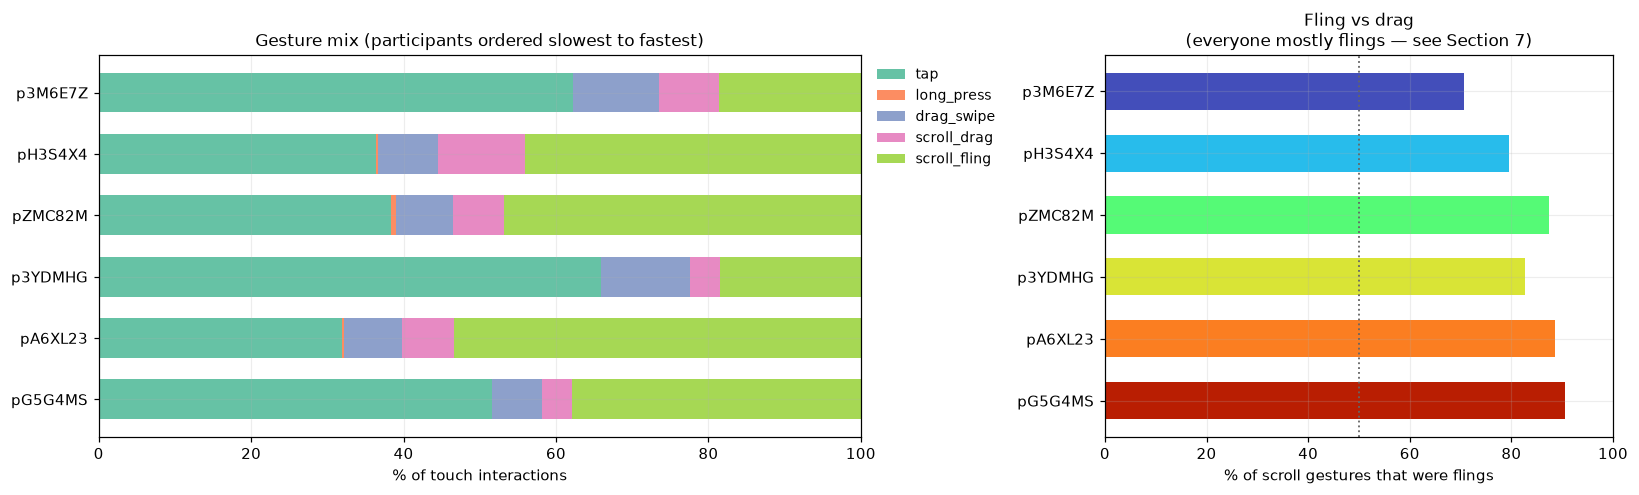

In [4]:
mix = (interactions.groupby(['participantId', 'gesture']).size()
       .unstack(fill_value=0).reindex(columns=GESTURE_CLASSES, fill_value=0))
mix_pct = mix.div(mix.sum(axis=1), axis=0).mul(100)
mix_pct = mix_pct.reindex([p for p in PARTICIPANT_ORDER if p in mix_pct.index])

fling_share = (interactions.loc[interactions['gesture'].str.startswith('scroll')]
               .assign(is_fling=lambda d: d['gesture'] == 'scroll_fling')
               .groupby('participantId')['is_fling'].mean().mul(100))


def plot_gesture_mix(mix_percent, fling_pct):
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={'width_ratios': [1.5, 1]})
    ax = axes[0]
    left = np.zeros(len(mix_percent))
    cmap = plt.get_cmap('Set2')
    for i, cls in enumerate(GESTURE_CLASSES):
        if cls not in mix_percent:
            continue
        ax.barh(range(len(mix_percent)), mix_percent[cls], left=left,
                color=cmap(i), label=cls, height=0.65)
        left += mix_percent[cls].to_numpy()
    ax.set_yticks(range(len(mix_percent))); ax.set_yticklabels(mix_percent.index)
    ax.invert_yaxis(); ax.set_xlim(0, 100)
    ax.set_xlabel("% of touch interactions")
    ax.set_title("Gesture mix (participants ordered slowest to fastest)")
    ax.legend(bbox_to_anchor=(1.005, 1), loc='upper left', frameon=False)

    ax = axes[1]
    f = fling_pct.reindex(mix_percent.index)
    ax.barh(range(len(f)), f, color=[pcolor(p) for p in f.index], height=0.6)
    ax.set_yticks(range(len(f))); ax.set_yticklabels(f.index); ax.invert_yaxis()
    ax.set_xlim(0, 100); ax.axvline(50, color='0.4', ls=':', lw=1.2)
    ax.set_xlabel("% of scroll gestures that were flings")
    ax.set_title("Fling vs drag\n(everyone mostly flings — see Section 7)")
    plt.tight_layout(); plt.show(); plt.close(fig)


print("Gesture mix, % of interactions:")
print(mix_pct.round(0).to_string())
print(f"\nFling share of scroll gestures: {fling_share.round(0).to_dict()}")
plot_gesture_mix(mix_pct, fling_share)

## 5. Scroll gesture morphology

Within scroll gestures only, the shape of the push:

- **`scroll_during_px`** — how far the content moved while the finger was down. This is
  the closest thing available to "how big a push does this person make", and Section 7
  shows it is the one scroll feature not standing in for pace.
- **`hold_ms`** — how long the finger stayed on the glass.
- **`scroll_efficiency`** — total content distance per millisecond of contact.
- **`scroll_coast_px`** — how far it ran on after release, which is set by release
  velocity as the OS computed it internally.

               scroll_during_px  hold_ms  scroll_efficiency  scroll_coast_px  coast_fraction  v_release_px_s  n_gestures
participantId                                                                                                           
p3M6E7Z                   125.0   1010.0               0.44            302.0            0.54          166.67          51
pH3S4X4                   124.0    540.0               0.73            295.0            0.66           75.00         371
pZMC82M                    91.0    208.0               2.07            382.0            0.80          181.82         151
p3YDMHG                    54.0    359.5               1.00            314.0            0.85          372.99          52
pA6XL23                   111.0    277.0               1.77            434.0            0.79          181.82         245
pG5G4MS                   159.0    276.0               2.57            600.0            0.79          121.21         191


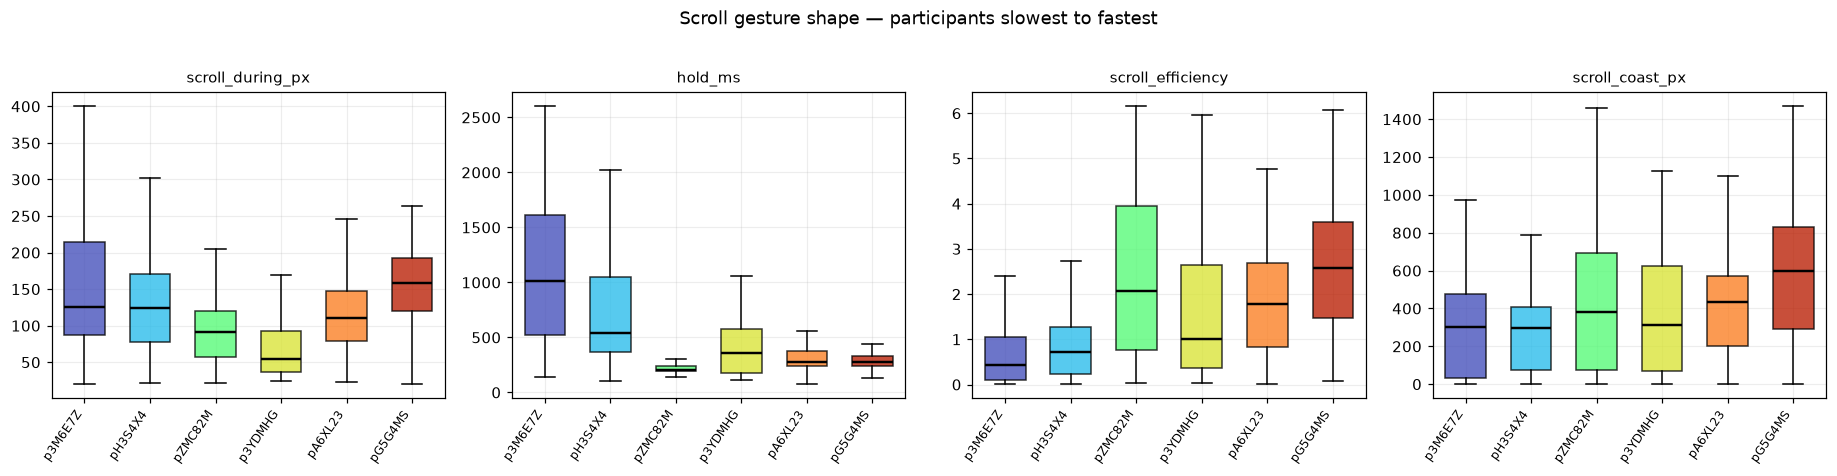

In [5]:
scroll_gestures = interactions.loc[interactions['gesture'].str.startswith('scroll')].copy()

SCROLL_FEATURES = ['scroll_during_px', 'hold_ms', 'scroll_efficiency',
                   'scroll_coast_px', 'coast_fraction', 'v_release_px_s']

profile = (scroll_gestures.groupby('participantId')[SCROLL_FEATURES].median()
           .reindex([p for p in PARTICIPANT_ORDER if p in set(scroll_gestures['participantId'])]))
profile['n_gestures'] = scroll_gestures.groupby('participantId').size()


def plot_scroll_morphology(gest):
    feats = ['scroll_during_px', 'hold_ms', 'scroll_efficiency', 'scroll_coast_px']
    fig, axes = plt.subplots(1, len(feats), figsize=(4.2 * len(feats), 4.2))
    for ax, f in zip(np.atleast_1d(axes), feats):
        data, labels, colors = [], [], []
        for p in PARTICIPANT_ORDER:
            v = gest.loc[gest['participantId'] == p, f].to_numpy(float)
            v = v[np.isfinite(v)]
            if len(v) < 5:
                continue
            data.append(v); labels.append(p); colors.append(pcolor(p))
        if not data:
            ax.set_axis_off(); continue
        bp = ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.62,
                        medianprops={'color': 'black', 'lw': 1.6})
        for patch, c in zip(bp['boxes'], colors):
            patch.set_facecolor(c); patch.set_alpha(0.78)
        ax.set_xticks(range(1, len(labels) + 1))
        ax.set_xticklabels(labels, rotation=55, ha='right', fontsize=8)
        ax.set_title(f, fontsize=10)
    fig.suptitle("Scroll gesture shape — participants slowest to fastest", y=1.02)
    plt.tight_layout(); plt.show(); plt.close(fig)


print(profile.round(2).to_string())
plot_scroll_morphology(scroll_gestures)

## 6. A feature that does not work, and why

Path **straightness** — displacement divided by path length — looks like an obvious
tremor measure. A steady hand drags in a straight line; an unsteady one wanders, making
the path longer than the straight-line distance, so the ratio should fall below 1.

It comes out **above 1** for every participant, which is geometrically impossible: the
shortest distance between two points cannot exceed the path taken.

The reason is that the browser **coalesces `touchmove` events**. It does not report every
intermediate position, so the reconstructed path is a chord-wise underestimate of the true
one, and the underestimate grows with gesture speed — exactly backwards for a tremor
measure, since it would penalise slow careful movements and reward fast sloppy ones.

This is recorded rather than quietly dropped so nobody re-derives it later. It becomes
usable only with `getCoalescedEvents()` in the logger, which is the same fix that would
sharpen every path-based feature.

In [6]:
drag_like = interactions.loc[interactions['gesture'].isin(['drag_swipe', 'scroll_drag',
                                                            'scroll_fling'])].copy()
drag_like = drag_like.loc[drag_like['path_len_px'] > 20]
drag_like['straightness'] = drag_like['displacement_px'] / drag_like['path_len_px']

_s = (drag_like.groupby('participantId')['straightness']
      .agg(n='size', median='median', frac_above_1=lambda s: float((s > 1).mean()))
      .reindex([p for p in PARTICIPANT_ORDER if p in set(drag_like['participantId'])]))
print("Path straightness (displacement / path length). Values > 1 are impossible.\n")
print(_s.round(3).to_string())
print(f"\nOverall: {(drag_like['straightness'] > 1).mean():.1%} of gestures exceed 1.0")
print("-> touchmove is coalesced; path length is undersampled. Feature rejected.")
print("   Revisit only if the logger adds getCoalescedEvents().")

_samp = (drag_like.groupby('participantId')['n_moves'].median()
         .reindex(_s.index))
print(f"\nMedian touchmove samples per gesture: {_samp.to_dict()}")
print("A gesture crossing 150px with only a handful of samples cannot describe a path.")

Path straightness (displacement / path length). Values > 1 are impossible.

                 n  median  frac_above_1
participantId                           
p3M6E7Z         73   1.015         0.685
pH3S4X4        424   1.029         0.748
pZMC82M        172   1.062         0.913
p3YDMHG         79   1.081         0.911
pA6XL23        276   1.049         0.895
pG5G4MS        221   1.046         0.923

Overall: 84.1% of gestures exceed 1.0
-> touchmove is coalesced; path length is undersampled. Feature rejected.
   Revisit only if the logger adds getCoalescedEvents().

Median touchmove samples per gesture: {'p3M6E7Z': 43.0, 'pH3S4X4': 24.0, 'pZMC82M': 10.0, 'p3YDMHG': 14.0, 'pA6XL23': 14.0, 'pG5G4MS': 14.0}
A gesture crossing 150px with only a handful of samples cannot describe a path.


## 7. Verdict — which of these are worth deriving

Two tests, the same pair used in notebook 05.

**Separability** is the rank-based AUC over every participant pair, at gesture level and
aggregated to P2's 7.5s CA window. `min` matters more than `mean`: a feature separating
the extremes and nothing else will not carry a verification system.

**Pace independence** is the correlation between each participant's median and their
median session duration. This project keeps rediscovering that features correlated with
pace are largely re-expressing tempo, and this notebook is no exception — most of the
scroll features turn out to be pace in disguise, with one clear exception.

In [7]:
CA_WINDOW_S, CA_STRIDE_S = 7.5, 2.5
MIN_GESTURES_PER_WINDOW = 2


def rank_auc(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    x = x[np.isfinite(x)]; y = y[np.isfinite(y)]
    if len(x) < 5 or len(y) < 5:
        return np.nan
    ranks = pd.Series(np.concatenate([x, y])).rank(method='average').to_numpy()
    return float((ranks[:len(x)].sum() - len(x) * (len(x) + 1) / 2) / (len(x) * len(y)))


def pairwise(df, feature):
    parts = [p for p in PARTICIPANT_ORDER if p in set(df['participantId'])]
    vals = {p: df.loc[df['participantId'] == p, feature].to_numpy(float) for p in parts}
    out = {}
    for i, a in enumerate(parts):
        for b in parts[i + 1:]:
            v = rank_auc(vals[a], vals[b])
            if np.isfinite(v):
                out[(a, b)] = max(v, 1 - v)
    return out


def to_windows(df, features, window_s=CA_WINDOW_S, stride_s=CA_STRIDE_S,
               min_n=MIN_GESTURES_PER_WINDOW):
    rows = []
    for (pid, sid), g in df.groupby(['participantId', 'sessionId']):
        end = g['t_rel_s'].max()
        lo = 0.0
        while lo + window_s <= end + stride_s:
            m = (g['t_rel_s'] >= lo) & (g['t_rel_s'] < lo + window_s)
            if m.sum() >= min_n:
                rec = {'participantId': pid, 'sessionId': sid, 'window_start_s': lo,
                       'n_gestures': int(m.sum())}
                rec.update(g.loc[m, features].median().to_dict())
                rows.append(rec)
            lo += stride_s
    return pd.DataFrame(rows)


CANDIDATES = ['scroll_during_px', 'hold_ms', 'scroll_efficiency', 'scroll_coast_px',
              'coast_fraction', 'v_release_px_s']

scroll_windows = to_windows(scroll_gestures, CANDIDATES)
_dur = session_index.groupby('participantId')['duration_s'].median()

_rows = []
for f in CANDIDATES:
    s_g, s_w = pairwise(scroll_gestures, f), pairwise(scroll_windows, f)
    med = scroll_gestures.groupby('participantId')[f].median()
    common = med.index.intersection(_dur.index)
    r = float(np.corrcoef(_dur[common], med[common])[0, 1]) if len(common) > 2 else np.nan
    _rows.append({'feature': f,
                  'gesture_mean': np.mean(list(s_g.values())) if s_g else np.nan,
                  'gesture_min': np.min(list(s_g.values())) if s_g else np.nan,
                  'window_mean': np.mean(list(s_w.values())) if s_w else np.nan,
                  'window_min': np.min(list(s_w.values())) if s_w else np.nan,
                  'pace_r': r})

# Gesture-mix share, computed PER WINDOW rather than per session. Per session there are
# only as many values as there are sessions, which is far too few to estimate an AUC --
# the shares would come back NaN and read as "does not separate" when the truth is
# "not testable at that granularity".
MIX_CLASSES = ['scroll_fling', 'tap', 'drag_swipe']


def mix_windows(df, classes=MIX_CLASSES, window_s=CA_WINDOW_S, stride_s=CA_STRIDE_S, min_n=3):
    rows = []
    for (pid, sid), g in df.groupby(['participantId', 'sessionId']):
        end = g['t_rel_s'].max()
        lo = 0.0
        while lo + window_s <= end + stride_s:
            m = (g['t_rel_s'] >= lo) & (g['t_rel_s'] < lo + window_s)
            if m.sum() >= min_n:
                sub = g.loc[m, 'gesture']
                rec = {'participantId': pid, 'sessionId': sid, 'window_start_s': lo,
                       'n_interactions': int(m.sum())}
                for c in classes:
                    rec[f'share_{c}'] = float((sub == c).mean())
                rows.append(rec)
            lo += stride_s
    return pd.DataFrame(rows)


gesture_mix_windows = mix_windows(interactions)

_mixrows = []
for cls in MIX_CLASSES:
    col = f'share_{cls}'
    s = pairwise(gesture_mix_windows, col)
    med = gesture_mix_windows.groupby('participantId')[col].median()
    common = med.index.intersection(_dur.index)
    r = float(np.corrcoef(_dur[common], med[common])[0, 1]) if len(common) > 2 else np.nan
    _mixrows.append({'feature': col, 'gesture_mean': np.nan, 'gesture_min': np.nan,
                     'window_mean': np.mean(list(s.values())) if s else np.nan,
                     'window_min': np.min(list(s.values())) if s else np.nan, 'pace_r': r})

morphology_scores = pd.concat([pd.DataFrame(_rows), pd.DataFrame(_mixrows)], ignore_index=True)

PACE_PROXY_R, WIN_MEAN_MIN = 0.70, 0.60


def decide(r):
    if not np.isfinite(r['window_mean']):
        return 'NO EVIDENCE', 'too few samples to estimate an AUC — not a negative result'
    if r['window_mean'] < WIN_MEAN_MIN:
        return 'EXCLUDE', 'does not separate at window level'
    if np.isfinite(r['pace_r']) and abs(r['pace_r']) >= PACE_PROXY_R:
        return 'HOLD', f"pace proxy (r={r['pace_r']:+.2f}); little added over timing features"
    return 'INCLUDE', f"separates and is pace-independent (r={r['pace_r']:+.2f})"


morphology_scores[['decision', 'reason']] = morphology_scores.apply(
    lambda r: pd.Series(decide(r)), axis=1)
morphology_scores = morphology_scores.sort_values(
    ['decision', 'window_mean'], ascending=[True, False]).reset_index(drop=True)

print(f"{len(scroll_windows):,} CA windows with >= {MIN_GESTURES_PER_WINDOW} scroll gestures\n")
for d in ['INCLUDE', 'HOLD', 'EXCLUDE', 'NO EVIDENCE']:
    sub = morphology_scores.loc[morphology_scores['decision'] == d]
    if sub.empty:
        continue
    print(f"{d}:")
    for r in sub.itertuples():
        print(f"   {r.feature:20s} win {r.window_mean:.3f} (min {r.window_min:.3f})  -> {r.reason}")
    print()
morphology_scores.round(3)

620 CA windows with >= 2 scroll gestures

INCLUDE:
   scroll_during_px     win 0.755 (min 0.541)  -> separates and is pace-independent (r=-0.02)
   v_release_px_s       win 0.679 (min 0.504)  -> separates and is pace-independent (r=-0.10)
   share_tap            win 0.661 (min 0.508)  -> separates and is pace-independent (r=+0.38)
   share_scroll_fling   win 0.627 (min 0.520)  -> separates and is pace-independent (r=-0.56)

HOLD:
   hold_ms              win 0.760 (min 0.518)  -> pace proxy (r=+0.91); little added over timing features
   scroll_efficiency    win 0.678 (min 0.521)  -> pace proxy (r=-0.80); little added over timing features
   scroll_coast_px      win 0.638 (min 0.506)  -> pace proxy (r=-0.71); little added over timing features
   coast_fraction       win 0.635 (min 0.503)  -> pace proxy (r=-0.88); little added over timing features

EXCLUDE:
   share_drag_swipe     win 0.524 (min 0.500)  -> does not separate at window level



/Users/will/Documents/BBDC-Prototype-2-Research/.venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/will/Documents/BBDC-Prototype-2-Research/.venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,feature,gesture_mean,gesture_min,window_mean,window_min,pace_r,decision,reason
0,share_drag_swipe,NaN,NaN,0.524,0.500,NaN,EXCLUDE,does not separate at window level
1,hold_ms,0.753,0.535,0.760,0.518,0.914,HOLD,pace proxy (r=+0.91); little added over timing...
2,scroll_efficiency,0.683,0.547,0.678,0.521,-0.797,HOLD,pace proxy (r=-0.80); little added over timing...
3,scroll_coast_px,0.609,0.515,0.638,0.506,-0.708,HOLD,pace proxy (r=-0.71); little added over timing...
4,coast_fraction,0.614,0.505,0.635,0.503,-0.884,HOLD,pace proxy (r=-0.88); little added over timing...
5,scroll_during_px,0.679,0.539,0.755,0.541,-0.024,INCLUDE,separates and is pace-independent (r=-0.02)
6,v_release_px_s,0.600,0.507,0.679,0.504,-0.102,INCLUDE,separates and is pace-independent (r=-0.10)
7,share_tap,NaN,NaN,0.661,0.508,0.377,INCLUDE,separates and is pace-independent (r=+0.38)
8,share_scroll_fling,NaN,NaN,0.627,0.520,-0.558,INCLUDE,separates and is pace-independent (r=-0.56)


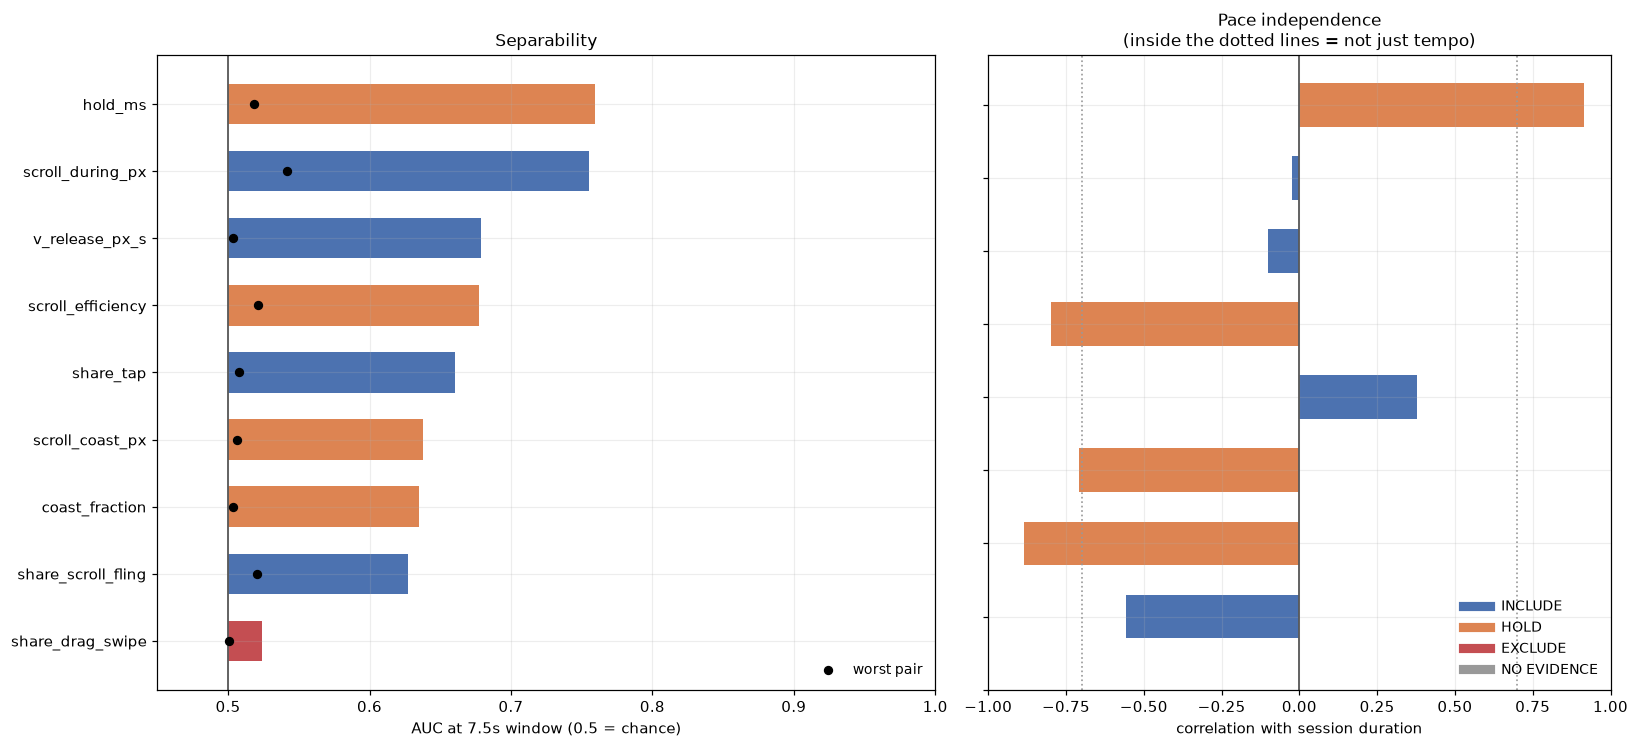

In [8]:
def plot_verdict(scores):
    d = scores.dropna(subset=['window_mean']).sort_values('window_mean')
    y = np.arange(len(d))
    fig, axes = plt.subplots(1, 2, figsize=(15, 0.5 * len(d) + 2.4),
                             gridspec_kw={'width_ratios': [1.25, 1]})
    cmap = {'INCLUDE': '#4c72b0', 'HOLD': '#dd8452', 'EXCLUDE': '#c44e52', 'NO EVIDENCE': '0.6'}
    ax = axes[0]
    ax.barh(y, d['window_mean'] - 0.5, left=0.5, height=0.6,
            color=[cmap[v] for v in d['decision']])
    ax.scatter(d['window_min'], y, color='black', s=26, zorder=3, label='worst pair')
    ax.axvline(0.5, color='0.35', lw=1.2)
    ax.set_yticks(y); ax.set_yticklabels(d['feature']); ax.set_xlim(0.45, 1.0)
    ax.set_xlabel("AUC at 7.5s window (0.5 = chance)")
    ax.set_title("Separability")
    ax.legend(loc='lower right', frameon=False)

    ax = axes[1]
    ax.barh(y, d['pace_r'], height=0.6, color=[cmap[v] for v in d['decision']])
    ax.axvline(0, color='0.35', lw=1.2)
    for x in (-0.7, 0.7):
        ax.axvline(x, color='0.6', ls=':', lw=1.1)
    ax.set_yticks(y); ax.set_yticklabels([]); ax.set_xlim(-1, 1)
    ax.set_xlabel("correlation with session duration")
    ax.set_title("Pace independence\n(inside the dotted lines = not just tempo)")
    handles = [Line2D([0], [0], color=c, lw=6, label=k) for k, c in cmap.items()]
    ax.legend(handles=handles, loc='lower right', frameon=False)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_verdict(morphology_scores)

## 8. Export and what this changes

The distance features carry a confound the timing features do not: **every pixel measure
scales with screen size**. A larger handset yields larger pushes for identical behaviour,
and with one device per participant that is indistinguishable from a personal style.

Two mitigations, neither free. Normalising distances by viewport height converts them to
screen-fractions and removes the first-order effect — worth doing, and it requires the
viewport dimensions to be in session metadata. And `scroll_efficiency` is already a ratio
of distance to time, so it cancels part of the scale, though it inherits pace instead.
This is the first place in the project where the device confound has a partial technical
fix rather than only a data-collection one.

In [9]:
OUT_DIR = Path("../../data/interim")
OUT_DIR.mkdir(parents=True, exist_ok=True)

gesture_mix_long = (interactions.groupby(['participantId', 'sessionId', 'gesture']).size()
                    .rename('n').reset_index())
gesture_mix_long['share'] = (gesture_mix_long['n'] /
                             gesture_mix_long.groupby(['participantId', 'sessionId'])['n']
                             .transform('sum'))

_exports = {
    'gesture_interactions.csv': interactions,
    'gesture_scroll_windows.csv': scroll_windows,
    'gesture_mix.csv': gesture_mix_long,
    'gesture_mix_windows.csv': gesture_mix_windows,
    'gesture_morphology_verdict.csv': morphology_scores,
}
for name, frame in _exports.items():
    frame.to_csv(OUT_DIR / name, index=False)
    print(f"wrote {OUT_DIR / name}  ({len(frame):,} rows)")

wrote ../../data/interim/gesture_interactions.csv  (2,240 rows)
wrote ../../data/interim/gesture_scroll_windows.csv  (620 rows)
wrote ../../data/interim/gesture_mix.csv  (56 rows)
wrote ../../data/interim/gesture_mix_windows.csv  (1,068 rows)
wrote ../../data/interim/gesture_morphology_verdict.csv  (9 rows)


## 9. Carry-forward

**For `build_windows_dataset.py`.** Classify every touch interaction first, then compute
features *within class*. Pooling a tap and a fling into one "touch duration" statistic
averages two different behaviours, which is what the pipeline does today. The per-window
set worth adding: gesture-class shares, and the median of the included morphology features
with a gesture count as the confidence term.

**Gesture class is a conditioning variable, not just a feature.** The same argument as
task affordance in notebook 04 — a tap and a fling should not be scored by the same model,
and class share is the natural weight.

**Two logger changes this notebook argues for.** `carousel_scroll` carries no position, so
horizontal scrolling is entirely invisible — thousands of events with nothing measurable.
And `getCoalescedEvents()` would make path-based features possible at all; without it,
Section 6's straightness measure and anything else built on path length is unusable.

**On what was learned about the behaviour itself.** The fling-versus-drag distinction that
motivated the notebook turns out to be real but mostly a restatement of pace. The durable
finding is that gesture *amplitude* — how far the finger travels per push — is
several-fold different between people and essentially unrelated to how fast they work.
That is a rarer thing in this dataset than a high AUC, because most of what separates
these participants has turned out to be tempo wearing different hats.
